In [1]:
import os, sys

# Root project
project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))

if project_root not in sys.path:
    sys.path.append(project_root)

print("Project root added to sys.path:", project_root)


import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
import torch.nn as nn
import torch
import random
from tqdm.autonotebook import tqdm
import seaborn as sns
from envs import NonStationaryEnv, IGTEnv
from basal_ganglia import train
import pickle

Project root added to sys.path: /Users/charithapalika/Desktop/Lab projects/Labsystem/Rossler/ROSSLER_CLEANED_FILES


/var/folders/9v/hs9qlpdx4791kpqgpt09stch0000gn/T/ipykernel_8940/2820135250.py:18: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


Project root added to sys.path: /Users/charithapalika/Desktop/Lab projects/Labsystem/Rossler/ROSSLER_CLEANED_FILES


## Hyperparameters


In [2]:
TRAILS = 100
EPOCHS = 100
NUM_BINS = 5
LR = 0.1 
NUM_ARMS = 4
SCALING_FACTOR = 100
REW_STD = 0
LOSS_STD = 0
VAR = 0.1

## Simulation

In [3]:
env = IGTEnv(mean_reward=np.array([100,100,50,50])/SCALING_FACTOR,
             std_reward=np.array([REW_STD,REW_STD,REW_STD,REW_STD])/SCALING_FACTOR,
             mean_loss=np.array([-250,-1250,-50,-250])/SCALING_FACTOR,
             std_loss=np.array([LOSS_STD,LOSS_STD,LOSS_STD,LOSS_STD])/SCALING_FACTOR)

In [ ]:
reward_monitor, arm_chosen_monitor, avg_counts,ip_monitor, dp_monitor,ep_monitor= train(env, 
                                                      trails = TRAILS, 
                                                      epochs = EPOCHS, 
                                                      lr = LR, 
                                                      bins = NUM_BINS,
                                                      STN_data = 'rossler', 
                                                      d1_amp=0.5,
                                                      d2_amp=0.1, #1
                                                      gpi_threshold=0.15,#0.18,
                                                      max_gpi_iters=50,
                                                      del_lim=None, train_IP = False, 
                                                      del_med = None, printing = False,
                                                      gpi_mean= 1, ep_0 = 0.1,
                                                      alpha_ep = 0.001,
                                                      eta_ep = 0.1,
                                                      baseline_ep = 0.02, ep_lim=None)



## Analysis

In [5]:
A_picks = avg_counts[0]
B_picks = avg_counts[1]
C_picks = avg_counts[2]
D_picks = avg_counts[3]

Avg_A_picks = torch.mean(A_picks, dim = 0)
Avg_B_picks = torch.mean(B_picks, dim = 0)
Avg_C_picks = torch.mean(C_picks, dim = 0)
Avg_D_picks = torch.mean(D_picks, dim = 0)

IGT_score = torch.mean(torch.add(C_picks, D_picks) - torch.add(A_picks, B_picks), dim = 0).squeeze().numpy()
IGT_dev = torch.std(torch.add(C_picks, D_picks) - torch.add(A_picks, B_picks), dim = 0)/torch.sqrt(torch.tensor(EPOCHS, dtype = torch.float32))
IGT_dev = IGT_dev.squeeze().numpy()

print(f'IGT score: {IGT_score} with SE of {IGT_dev}')

IGT score: [-2.    1.16  0.34  4.96  7.64] with SE of [1.6839107 1.7734702 1.560382  1.4695508 1.2502542]


In [6]:
A_picks = avg_counts[0]
B_picks = avg_counts[1]
C_picks = avg_counts[2]
D_picks = avg_counts[3]

Avg_A_picks = torch.mean(A_picks, dim = 0)
Avg_B_picks = torch.mean(B_picks, dim = 0)
Avg_C_picks = torch.mean(C_picks, dim = 0)
Avg_D_picks = torch.mean(D_picks, dim = 0)

IP_A = torch.mean(ip_monitor[0], dim = 0).detach().numpy()
IP_B = torch.mean(ip_monitor[1], dim = 0).detach().numpy()
IP_C = torch.mean(ip_monitor[2], dim = 0).detach().numpy()
IP_D = torch.mean(ip_monitor[3], dim = 0).detach().numpy()

DP_A = torch.mean(dp_monitor[0], dim = 0).detach().numpy()
DP_B = torch.mean(dp_monitor[1], dim = 0).detach().numpy()
DP_C = torch.mean(dp_monitor[2], dim = 0).detach().numpy()
DP_D = torch.mean(dp_monitor[3], dim = 0).detach().numpy()

IGT_score = torch.mean(torch.add(C_picks, D_picks) - torch.add(A_picks, B_picks), dim = 0)
IGT_dev = torch.std(torch.add(C_picks, D_picks) - torch.add(A_picks, B_picks), dim = 0)/torch.sqrt(torch.tensor(EPOCHS, dtype = torch.float32))

IP_all = np.array([IP_A[:,0],IP_B[:,0],IP_C[:,0],IP_D[:,0]])
IP_Var = np.std(IP_all,axis = 0 )

## Results

Text(0.5, 0, 'trails')

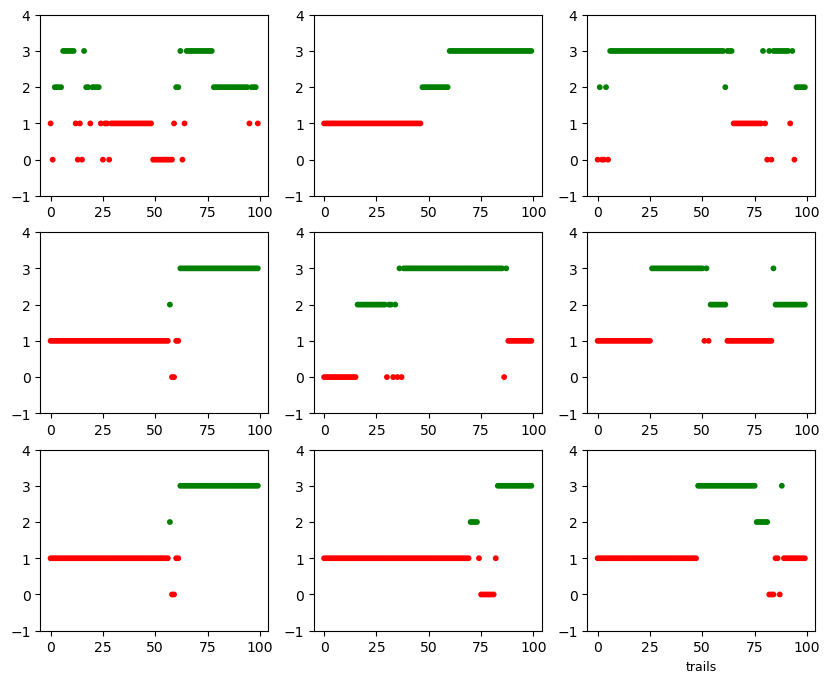

In [7]:
random_pick = np.random.choice(np.arange(EPOCHS), size = 9)

plt.figure(figsize=(10,8))
for i in range(9):
    plt.subplot(3,3,i+1)
    colors = np.where(np.isin(arm_chosen_monitor[random_pick[i]],[0,1]), 'r', 'g')
    plt.scatter(np.arange(TRAILS), arm_chosen_monitor[random_pick[i]], c = colors, s = 10)
    plt.ylim(-1,4)
plt.xlabel('trails', fontsize = 9)


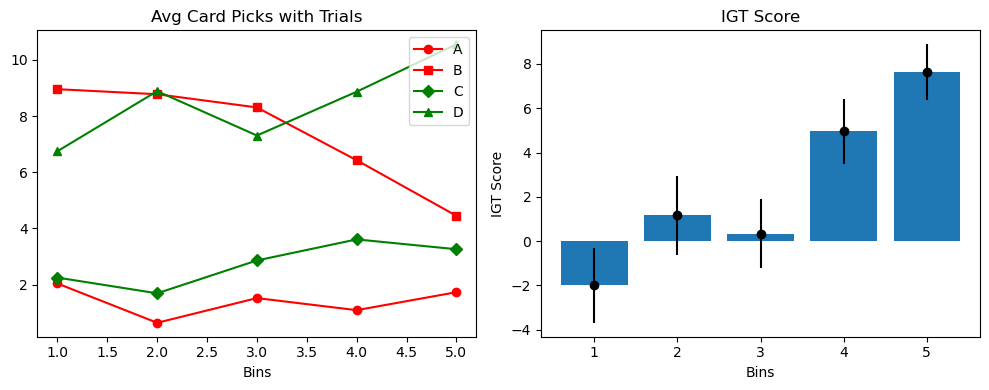

In [16]:
BINS = np.arange(5) + 1

plt.figure(figsize=(10, 4))


# 1. Average card picks with trials
plt.subplot(121)

plt.plot(BINS, Avg_A_picks, label='A', color='red', marker='o')
plt.plot(BINS, Avg_B_picks, label='B', color='red', marker='s')
plt.plot(BINS, Avg_C_picks, label='C', color='green', marker='D')
plt.plot(BINS, Avg_D_picks, label='D', color='green', marker='^')

plt.title('Avg Card Picks with Trials')
plt.xlabel('Bins')
plt.legend(loc='upper right')


# 2. IGT score
plt.subplot(122)

plt.bar(BINS, IGT_score.reshape(5))


plt.errorbar(
    BINS,
    IGT_score.reshape(5),
    yerr=IGT_dev.reshape(5),
    fmt='o',
    color='black'
)

plt.title('IGT Score')
plt.xlabel('Bins')
plt.ylabel('IGT Score')


plt.tight_layout()
plt.show()